# Online Retail II — Cohort retention analysis

Stage 4 of the customer analytics pipeline. Builds monthly cohort retention from the cleaned Stage 2 transaction dataset.

**Active customer:** a customer is considered active in a given month if they have at least one transaction in that calendar month. Sporadic activity (active, dormant, active again) is treated as active in each month with a transaction; this is the standard cohort retention convention.

**Input:** `data/processed/online_retail_cleaned.parquet`  
**Outputs:** `cohort_retention_long.parquet`, `cohort_retention_matrix.parquet`, `cohort_active_customer_matrix.parquet`, `cohort_sizes.parquet`

## Setup and baseline validation

Load `online_retail_cleaned.parquet` and validate it against the Stage 2 baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api import types as pandas_types
from pathlib import Path

In [2]:
cleaned_path = Path("../data/processed/online_retail_cleaned.parquet")
retail = pd.read_parquet(cleaned_path)

print(f"Loaded: {cleaned_path}")
print(f"Shape: {retail.shape}")
print(f"Memory: {retail.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Loaded: ..\data\processed\online_retail_cleaned.parquet
Shape: (776579, 9)
Memory: 91.8 MB


In [3]:
# Stage 2 baseline values
expected_row_count = 776_579
expected_column_count = 9
expected_unique_customers = 5_852
expected_unique_invoices = 36_594
expected_minimum_date = pd.Timestamp("2009-12-01")
expected_maximum_date = pd.Timestamp("2011-12-09")
expected_total_revenue = 17_068_582.72

assert retail.shape == (expected_row_count, expected_column_count), (
    f"Shape mismatch: got {retail.shape}"
)

actual_unique_customers = retail["Customer ID"].nunique()
actual_unique_invoices = retail["Invoice"].nunique()
actual_minimum_date = retail["InvoiceDate"].min()
actual_maximum_date = retail["InvoiceDate"].max()
actual_total_revenue = retail["Revenue"].sum()

assert actual_unique_customers == expected_unique_customers, (
    f"Unique customers: got {actual_unique_customers}"
)
assert actual_unique_invoices == expected_unique_invoices, (
    f"Unique invoices: got {actual_unique_invoices}"
)
assert actual_minimum_date.normalize() == expected_minimum_date, (
    f"Min date: got {actual_minimum_date}"
)
assert actual_maximum_date.normalize() == expected_maximum_date, (
    f"Max date: got {actual_maximum_date}"
)
assert abs(actual_total_revenue - expected_total_revenue) < 0.01, (
    f"Revenue: got £{actual_total_revenue:,.2f}"
)

print("Baseline validation passed.")
print(f"  Rows: {len(retail):,}")
print(f"  Unique customers: {actual_unique_customers:,}")
print(f"  Unique invoices: {actual_unique_invoices:,}")
print(f"  Date range: {actual_minimum_date.date()} to {actual_maximum_date.date()}")
print(f"  Total revenue: £{actual_total_revenue:,.2f}")

Baseline validation passed.
  Rows: 776,579
  Unique customers: 5,852
  Unique invoices: 36,594
  Date range: 2009-12-01 to 2011-12-09
  Total revenue: £17,068,582.72


In [4]:
dtype_checks = {
    "Invoice": pandas_types.is_string_dtype,
    "StockCode": pandas_types.is_string_dtype,
    "Description": pandas_types.is_string_dtype,
    "Quantity": pandas_types.is_integer_dtype,
    "InvoiceDate": pandas_types.is_datetime64_any_dtype,
    "Price": pandas_types.is_numeric_dtype,
    "Customer ID": pandas_types.is_integer_dtype,
    "Country": pandas_types.is_string_dtype,
    "Revenue": pandas_types.is_numeric_dtype,
}

for column_name, predicate in dtype_checks.items():
    assert predicate(retail[column_name]), (
        f"'{column_name}' has dtype {retail[column_name].dtype}, "
        f"failed {predicate.__name__}"
    )

print("Semantic dtype validation passed.")
print(retail.dtypes.to_string())

Semantic dtype validation passed.
Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID             Int64
Country                   str
Revenue               float64


## Build analysis dataframe

Filter to complete months (exclude December 2011), then add `invoice_month`, `cohort_month`, and `cohort_period` columns. This is the single source of truth for everything downstream — re-running this cell rebuilds the analysis dataframe in a known-good state.

In [5]:
# Exclude December 2011 because it is an incomplete observation month.
analysis_window_end_exclusive = pd.Timestamp("2011-12-01")
retail_analysis = retail[
    retail["InvoiceDate"] < analysis_window_end_exclusive
].copy()

# Track the row-count impact of excluding the incomplete month.
original_row_count = len(retail)
analysis_row_count = len(retail_analysis)
excluded_row_count = original_row_count - analysis_row_count
excluded_transactions = retail[
    retail["InvoiceDate"] >= analysis_window_end_exclusive
]

# Add invoice_month: calendar month of each transaction.
retail_analysis["invoice_month"] = (
    retail_analysis["InvoiceDate"].dt.to_period("M")
)

# Add cohort_month: each customer's first observed purchase month.
retail_analysis["cohort_month"] = (
    retail_analysis.groupby("Customer ID")["invoice_month"].transform("min")
)

# Add cohort_period: integer months between cohort_month and invoice_month.
retail_analysis["cohort_period"] = (
    retail_analysis["invoice_month"].astype("int64")
    - retail_analysis["cohort_month"].astype("int64")
)

# Reconciliation: filtered + excluded must equal original.
assert original_row_count == 776_579, "Unexpected original row count."
assert analysis_row_count + excluded_row_count == original_row_count

# Analysis window must contain only complete months.
assert retail_analysis["InvoiceDate"].max() < analysis_window_end_exclusive
assert excluded_transactions["InvoiceDate"].min() >= analysis_window_end_exclusive
assert retail_analysis["InvoiceDate"].min().normalize() == pd.Timestamp("2009-12-01")

# invoice_month: no nulls, expected period bounds, 24 unique months.
assert retail_analysis["invoice_month"].notna().all()
assert retail_analysis["invoice_month"].min() == pd.Period("2009-12", freq="M")
assert retail_analysis["invoice_month"].max() == pd.Period("2011-11", freq="M")
assert retail_analysis["invoice_month"].nunique() == 24

# cohort_month: every customer has exactly one cohort, cohort <= invoice_month.
assert retail_analysis["cohort_month"].notna().all()
assert (
    retail_analysis["cohort_month"] <= retail_analysis["invoice_month"]
).all()
customer_cohort_pairs = (
    retail_analysis[["Customer ID", "cohort_month"]].drop_duplicates()
)
assert len(customer_cohort_pairs) == retail_analysis["Customer ID"].nunique()

# cohort_period: non-negative, max equals analysis-window span.
assert retail_analysis["cohort_period"].notna().all()
assert (retail_analysis["cohort_period"] >= 0).all()
expected_maximum_period = (
    retail_analysis["invoice_month"].max().ordinal
    - retail_analysis["cohort_month"].min().ordinal
)
assert retail_analysis["cohort_period"].max() == expected_maximum_period
assert expected_maximum_period == 23

print(f"Original rows:        {original_row_count:,}")
print(f"Analysis rows:        {analysis_row_count:,}")
print(f"Excluded rows:        {excluded_row_count:,}")
print(f"Analysis customers:   {retail_analysis['Customer ID'].nunique():,}")
print(f"Date range:           {retail_analysis['InvoiceDate'].min().date()} "
      f"to {retail_analysis['InvoiceDate'].max().date()}")
print(f"Unique cohorts:       {retail_analysis['cohort_month'].nunique()}")
print(f"Cohort period range:  0 to {retail_analysis['cohort_period'].max()}")
print()
print(retail_analysis[["Customer ID", "InvoiceDate", "invoice_month",
                       "cohort_month", "cohort_period"]].head())

Original rows:        776,579
Analysis rows:        759,615
Excluded rows:        16,964
Analysis customers:   5,824
Date range:           2009-12-01 to 2011-11-30
Unique cohorts:       24
Cohort period range:  0 to 23

   Customer ID         InvoiceDate invoice_month cohort_month  cohort_period
0        13085 2009-12-01 07:45:00       2009-12      2009-12              0
1        13085 2009-12-01 07:45:00       2009-12      2009-12              0
2        13085 2009-12-01 07:45:00       2009-12      2009-12              0
3        13085 2009-12-01 07:45:00       2009-12      2009-12              0
4        13085 2009-12-01 07:45:00       2009-12      2009-12              0


## Build cohort sizes

Count unique customers per cohort. This is the denominator for the retention rate.

In [6]:
# One row per customer with their cohort_month. Using drop_duplicates()
# on the two-column subset is cleaner than groupby + first(), and
# correctness is supported by the one-cohort-per-customer validation in cohort_month assignment.
customer_cohort_lookup = (
    retail_analysis[["Customer ID", "cohort_month"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# The lookup table should contain exactly one row per unique customer.
assert len(customer_cohort_lookup) == retail_analysis["Customer ID"].nunique(), (
    "Customer-cohort lookup does not contain exactly one row per customer."
)

# Count customers whose first observed purchase month is each cohort month.
cohort_sizes = (
    customer_cohort_lookup
    .groupby("cohort_month")
    .size()
    .reset_index(name="cohort_size")
)

# The cohort size table should contain one row per observed cohort.
assert len(cohort_sizes) == retail_analysis["cohort_month"].nunique(), (
    "Number of cohort_size rows does not match unique cohorts."
)

# Every observed cohort must have at least one customer.
assert (cohort_sizes["cohort_size"] > 0).all(), (
    "At least one observed cohort has size zero."
)

# Cohort sizes must sum to the total customer count in the analysis dataset.
assert cohort_sizes["cohort_size"].sum() == retail_analysis["Customer ID"].nunique(), (
    "Sum of cohort sizes does not match total unique customers."
)

print(f"Cohorts: {len(cohort_sizes)}")
print(f"Total customers across cohorts: {cohort_sizes['cohort_size'].sum():,}")
print(f"Largest cohort: {cohort_sizes['cohort_size'].max():,} customers")
print(f"Smallest cohort: {cohort_sizes['cohort_size'].min():,} customers")
print()
print(cohort_sizes.to_string(index=False))

Cohorts: 24
Total customers across cohorts: 5,824
Largest cohort: 951 customers
Smallest cohort: 72 customers

cohort_month  cohort_size
     2009-12          951
     2010-01          368
     2010-02          375
     2010-03          441
     2010-04          294
     2010-05          255
     2010-06          267
     2010-07          185
     2010-08          163
     2010-09          239
     2010-10          375
     2010-11          326
     2010-12           76
     2011-01           72
     2011-02          125
     2011-03          179
     2011-04          106
     2011-05          111
     2011-06          108
     2011-07          101
     2011-08          107
     2011-09          188
     2011-10          221
     2011-11          191


## Count active customers by cohort and period

Group transactions by `cohort_month` and `cohort_period`, counting unique customers per group.

In [7]:
# Count unique active customers per cohort-period combination.
# nunique() deduplicates within each group, so a customer with multiple
# transactions in the same period counts once.
active_customer_counts = (
    retail_analysis
    .groupby(["cohort_month", "cohort_period"])["Customer ID"]
    .nunique()
    .reset_index(name="active_customer_count")
)

# The grouped result should contain no duplicate cohort-period rows.
assert not active_customer_counts.duplicated(
    subset=["cohort_month", "cohort_period"]
).any(), (
    "Duplicate cohort-period combinations found."
)

# Active counts must be positive because groupby only returns observed activity.
assert (active_customer_counts["active_customer_count"] > 0).all(), (
    "Zero active_customer_count values present unexpectedly."
)

# Cross-check: period-0 active count must equal cohort_size for every cohort.
# This validates that cohort_month assignment and cohort_sizes are consistent
# with the transaction-level activity data.
period_zero_counts = (
    active_customer_counts[active_customer_counts["cohort_period"] == 0]
    .rename(columns={"active_customer_count": "period_zero_count"})
    .drop(columns="cohort_period")
)

cross_check = cohort_sizes.merge(
    period_zero_counts,
    on="cohort_month",
    how="outer",
)

assert cross_check["cohort_size"].notna().all(), (
    "Period-0 active counts contain a cohort missing from cohort_sizes."
)

assert cross_check["period_zero_count"].notna().all(), (
    "At least one cohort from cohort_sizes is missing a period-0 active count."
)

assert (cross_check["cohort_size"] == cross_check["period_zero_count"]).all(), (
    "Period-0 active count does not equal cohort_size for at least one cohort."
)

# Active customers in any period cannot exceed the original cohort size.
active_counts_with_sizes = active_customer_counts.merge(
    cohort_sizes,
    on="cohort_month",
    how="left",
)

assert active_counts_with_sizes["cohort_size"].notna().all(), (
    "At least one active count row is missing its cohort_size."
)

assert (
    active_counts_with_sizes["active_customer_count"]
    <= active_counts_with_sizes["cohort_size"]
).all(), (
    "Active customer count exceeds cohort_size for at least one cohort-period."
)

assert active_customer_counts["cohort_period"].min() == 0, (
    "Unexpected minimum cohort_period."
)

assert active_customer_counts["cohort_period"].max() == 23, (
    "Unexpected maximum cohort_period."
)

cohort_count = len(cohort_sizes)

print(f"Observed active cohort-period rows: {len(active_customer_counts):,}")
print(f"Unique cohorts present: {active_customer_counts['cohort_month'].nunique()}")
print(
    f"Period range: {active_customer_counts['cohort_period'].min()} "
    f"to {active_customer_counts['cohort_period'].max()}"
)
print(
    "Cross-check passed: period-0 active count equals "
    f"cohort_size for all {cohort_count} cohorts."
)
print()
print("First 10 rows:")
print(active_customer_counts.head(10).to_string(index=False))

Observed active cohort-period rows: 300
Unique cohorts present: 24
Period range: 0 to 23
Cross-check passed: period-0 active count equals cohort_size for all 24 cohorts.

First 10 rows:
cohort_month  cohort_period  active_customer_count
     2009-12              0                    951
     2009-12              1                    333
     2009-12              2                    317
     2009-12              3                    404
     2009-12              4                    360
     2009-12              5                    342
     2009-12              6                    358
     2009-12              7                    327
     2009-12              8                    321
     2009-12              9                    344


## Create observable cohort-period grid

Build the full set of observable cohort-period combinations. Cells observable but absent from the active-counts table are filled with zero; cells beyond a cohort's observable window stay NaN.

In [8]:
# Final complete analysis month: the right edge of the observable window.
# This determines the maximum observable period for each cohort.
final_analysis_month = retail_analysis["invoice_month"].max()

assert final_analysis_month == pd.Period("2011-11", freq="M"), (
    "Unexpected final analysis month."
)

# Compute the maximum observable period for each cohort.
cohort_observable_windows = cohort_sizes[["cohort_month"]].copy()
cohort_observable_windows["max_observable_period"] = (
    final_analysis_month.ordinal
    - cohort_observable_windows["cohort_month"].astype("int64")
)

# Observable periods should run from 0 for the latest cohort to 23 for 2009-12.
assert cohort_observable_windows["max_observable_period"].min() == 0, (
    "Unexpected minimum observable period."
)

assert cohort_observable_windows["max_observable_period"].max() == 23, (
    "Unexpected maximum observable period."
)

# Expand each cohort into one row per observable period.
# This creates the complete triangular grid before active counts are joined.
observable_grid = cohort_observable_windows.copy()
observable_grid["cohort_period"] = observable_grid["max_observable_period"].apply(
    lambda max_period: list(range(max_period + 1))
)

observable_grid = (
    observable_grid
    .explode("cohort_period")
    .drop(columns="max_observable_period")
    .reset_index(drop=True)
)

observable_grid["cohort_period"] = observable_grid["cohort_period"].astype("int64")

# Expected grid size is the sum of each cohort's observable period count.
expected_grid_rows = (
    cohort_observable_windows["max_observable_period"] + 1
).sum()

assert len(observable_grid) == expected_grid_rows, (
    "Observable grid row count does not match the expected observable window size."
)

# Validate that every active cohort-period row is observable.
active_rows_grid_check = active_customer_counts.merge(
    observable_grid,
    on=["cohort_month", "cohort_period"],
    how="left",
    indicator=True,
)

assert active_rows_grid_check["_merge"].eq("both").all(), (
    "At least one active cohort-period row is missing from the observable grid."
)

# Left-join active counts onto the grid.
# Missing values inside the grid are observable zero-active cells.
cohort_grid = observable_grid.merge(
    active_customer_counts,
    on=["cohort_month", "cohort_period"],
    how="left",
)

cohort_grid["active_customer_count"] = (
    cohort_grid["active_customer_count"].fillna(0).astype("int64")
)

# The joined grid should contain no duplicate cohort-period rows.
assert not cohort_grid.duplicated(
    subset=["cohort_month", "cohort_period"]
).any(), (
    "Duplicate cohort-period rows in grid."
)

# Active counts must be non-negative. Zeros are valid after grid construction.
assert (cohort_grid["active_customer_count"] >= 0).all(), (
    "Negative active_customer_count after grid join."
)

# Period 0 must exist for every cohort.
period_zero_grid = cohort_grid[cohort_grid["cohort_period"] == 0]

assert len(period_zero_grid) == len(cohort_sizes), (
    "Period-0 row missing from grid for at least one cohort."
)

# Period 0 active count should still equal cohort size after grid construction.
period_zero_grid_check = period_zero_grid.merge(
    cohort_sizes,
    on="cohort_month",
    how="left",
)

assert (
    period_zero_grid_check["active_customer_count"]
    == period_zero_grid_check["cohort_size"]
).all(), (
    "Period-0 active count does not equal cohort_size after grid construction."
)

# Count observable zero cells introduced by the grid.
observable_zero_count = (
    cohort_grid["active_customer_count"].eq(0).sum()
)

print(f"Final analysis month: {final_analysis_month}")
print(f"Grid rows (observable cells): {len(cohort_grid):,}")
print(f"Observed active rows: {len(active_customer_counts):,}")
print(f"Observable zero cells filled with 0: {observable_zero_count:,}")
print()

print("Grid head:")
print(cohort_grid.head(10).to_string(index=False))
print()

print("Grid tail (latest cohorts, fewest observable periods):")
print(cohort_grid.tail(10).to_string(index=False))

Final analysis month: 2011-11
Grid rows (observable cells): 300
Observed active rows: 300
Observable zero cells filled with 0: 0

Grid head:
cohort_month  cohort_period  active_customer_count
     2009-12              0                    951
     2009-12              1                    333
     2009-12              2                    317
     2009-12              3                    404
     2009-12              4                    360
     2009-12              5                    342
     2009-12              6                    358
     2009-12              7                    327
     2009-12              8                    321
     2009-12              9                    344

Grid tail (latest cohorts, fewest observable periods):
cohort_month  cohort_period  active_customer_count
     2011-08              0                    107
     2011-08              1                     28
     2011-08              2                     32
     2011-08              3           

## Long-form retention table

Add `cohort_size` and `retention_rate` to the observable grid. This is the main analytical output.

In [9]:
# Attach cohort_size to every grid row, then compute retention_rate as
# active_customer_count divided by cohort_size. Long-form is the
# canonical analytical output for downstream tools.
cohort_retention_long = cohort_grid.merge(
    cohort_sizes,
    on="cohort_month",
    how="left",
)

# Every grid row must have a matching cohort_size after the join.
assert cohort_retention_long["cohort_size"].notna().all(), (
    "At least one grid row is missing cohort_size after join."
)

# Active customer count cannot exceed the original cohort size.
assert (
    cohort_retention_long["active_customer_count"]
    <= cohort_retention_long["cohort_size"]
).all(), (
    "active_customer_count exceeds cohort_size for at least one row."
)

cohort_retention_long["retention_rate"] = (
    cohort_retention_long["active_customer_count"]
    / cohort_retention_long["cohort_size"]
)

# Keep the long-form output in a clear analytical column order.
cohort_retention_long = cohort_retention_long[
    [
        "cohort_month",
        "cohort_period",
        "active_customer_count",
        "cohort_size",
        "retention_rate",
    ]
]

# Row count must match the grid because the merge is many-to-one by cohort_month.
assert len(cohort_retention_long) == len(cohort_grid), (
    "Row count changed during cohort_size merge."
)

# Period 0 retention must be 1.0 for every cohort.
period_zero_retention = cohort_retention_long[
    cohort_retention_long["cohort_period"] == 0
]

assert np.isclose(period_zero_retention["retention_rate"], 1.0).all(), (
    "Period-0 retention rate is not 1.0 for at least one cohort."
)

# All retention rates must lie in [0, 1].
assert (cohort_retention_long["retention_rate"] >= 0).all(), (
    "Negative retention_rate found."
)

assert (cohort_retention_long["retention_rate"] <= 1.0).all(), (
    "Retention rate exceeds 1.0 for at least one row."
)

# The long-form table should contain one row per observable cohort-period cell.
assert not cohort_retention_long.duplicated(
    subset=["cohort_month", "cohort_period"]
).any(), (
    "Duplicate cohort-period rows in long-form table."
)

print(f"Long-form retention rows: {len(cohort_retention_long):,}")
print(f"Unique cohorts: {cohort_retention_long['cohort_month'].nunique()}")
print(
    f"Period range: {cohort_retention_long['cohort_period'].min()} "
    f"to {cohort_retention_long['cohort_period'].max()}"
)
print()

print("Head (earliest cohort, first 6 observable periods):")
print(
    cohort_retention_long.head(6)
    .assign(retention_rate=lambda data: data["retention_rate"].round(4))
    .to_string(index=False)
)

Long-form retention rows: 300
Unique cohorts: 24
Period range: 0 to 23

Head (earliest cohort, first 6 observable periods):
cohort_month  cohort_period  active_customer_count  cohort_size  retention_rate
     2009-12              0                    951          951          1.0000
     2009-12              1                    333          951          0.3502
     2009-12              2                    317          951          0.3333
     2009-12              3                    404          951          0.4248
     2009-12              4                    360          951          0.3785
     2009-12              5                    342          951          0.3596


## Retention matrix

Pivot `cohort_retention_long` to cohort × period. Unobservable cells are NaN.

In [10]:
# Pivot long-form retention to a cohort × period wide matrix.
# Unobservable cells become NaN.
retention_matrix = cohort_retention_long.pivot(
    index="cohort_month",
    columns="cohort_period",
    values="retention_rate",
)

# Matrix should be 24 cohorts × 24 period offsets.
assert retention_matrix.shape == (24, 24), (
    f"Unexpected matrix shape: {retention_matrix.shape}"
)

# Period 0 must be exactly 1.0 for every cohort.
assert retention_matrix[0].notna().all(), (
    "Period-0 column contains NaN values."
)
assert np.isclose(retention_matrix[0], 1.0).all(), (
    "Period-0 column is not 1.0 for every cohort."
)

# Non-NaN cell count must equal the long-form row count.
non_nan_cell_count = retention_matrix.notna().sum().sum()
assert non_nan_cell_count == len(cohort_retention_long), (
    f"Matrix non-NaN cells ({non_nan_cell_count}) does not match "
    f"long-form row count ({len(cohort_retention_long)})."
)

# Observed values must lie in [0, 1]. dropna avoids NaN poisoning the comparison.
observed_values = retention_matrix.stack().dropna()
assert (observed_values >= 0).all() and (observed_values <= 1.0).all(), (
    "Observed retention values outside [0, 1] range."
)

print(f"Matrix shape: {retention_matrix.shape}")
print(f"Non-NaN cells: {non_nan_cell_count}")
print(f"NaN cells (unobservable): {retention_matrix.isna().sum().sum()}")
print()
print("Matrix preview (first 6 cohorts, first 8 periods):")
print(retention_matrix.iloc[:6, :8].round(4).to_string())

Matrix shape: (24, 24)
Non-NaN cells: 300
NaN cells (unobservable): 276

Matrix preview (first 6 cohorts, first 8 periods):
cohort_period    0       1       2       3       4       5       6       7
cohort_month                                                              
2009-12        1.0  0.3502  0.3333  0.4248  0.3785  0.3596  0.3764  0.3438
2010-01        1.0  0.2147  0.3207  0.3152  0.2717  0.3098  0.2690  0.2337
2010-02        1.0  0.2347  0.2267  0.2933  0.2453  0.1973  0.1920  0.2880
2010-03        1.0  0.1905  0.2313  0.2426  0.2313  0.2041  0.2472  0.3061
2010-04        1.0  0.1905  0.1905  0.1599  0.1837  0.2211  0.2755  0.2653
2010-05        1.0  0.1569  0.1686  0.1765  0.1765  0.2549  0.2118  0.1255


## Retention heatmap

Visualise the retention matrix as a heatmap. Unobservable cells render blank.

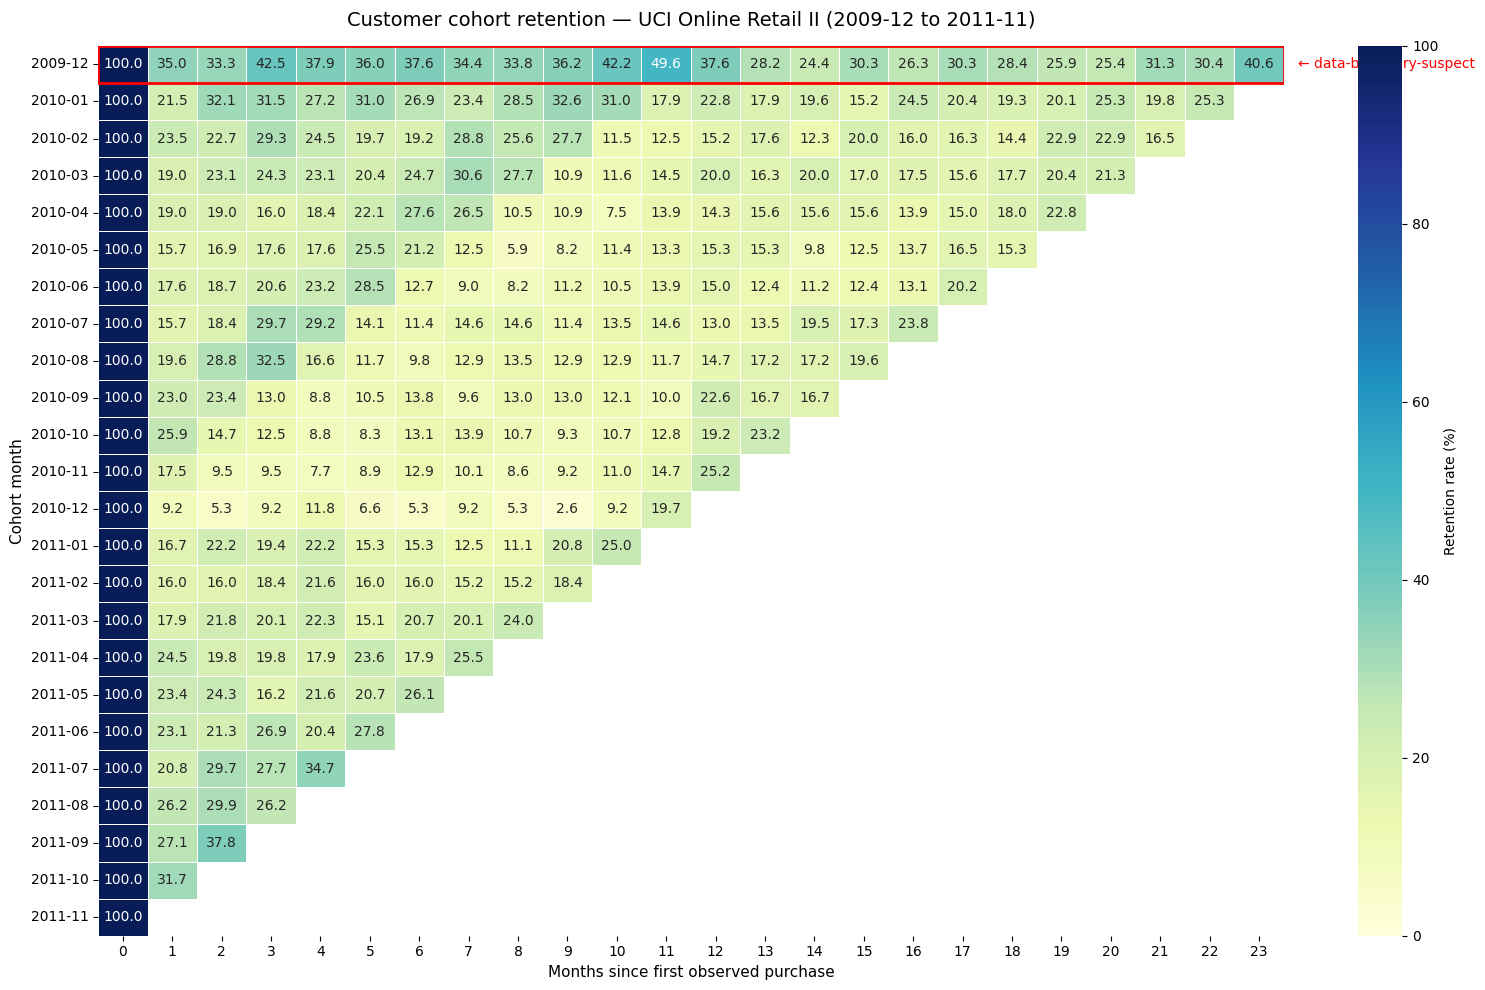

In [11]:
# Display matrix: percentages with cleaner y-axis labels.
display_matrix = retention_matrix * 100
display_matrix.index = display_matrix.index.astype(str)

figure, axis = plt.subplots(figsize=(16, 10))

sns.heatmap(
    display_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Retention rate (%)"},
    linewidths=0.5,
    linecolor="white",
    ax=axis,
)

# Highlight 2009-12 as data-boundary-suspect: customers in this cohort
# may include pre-existing customers whose earlier purchases fall outside
# the analysis window.
suspect_cohort_label = "2009-12"
suspect_row_index = list(display_matrix.index).index(suspect_cohort_label)
axis.add_patch(
    plt.Rectangle(
        (0, suspect_row_index),
        display_matrix.shape[1],
        1,
        fill=False,
        edgecolor="red",
        linewidth=2,
    )
)
axis.text(
    display_matrix.shape[1] + 0.3,
    suspect_row_index + 0.5,
    "← data-boundary-suspect",
    color="red",
    fontsize=10,
    va="center",
)

axis.set_title(
    "Customer cohort retention — UCI Online Retail II (2009-12 to 2011-11)",
    fontsize=14,
    pad=15,
)
axis.set_xlabel("Months since first observed purchase", fontsize=11)
axis.set_ylabel("Cohort month", fontsize=11)
plt.tight_layout()
plt.show()

## 2009-12 sensitivity check

Compare the average retention curve including and excluding the 2009-12 cohort.

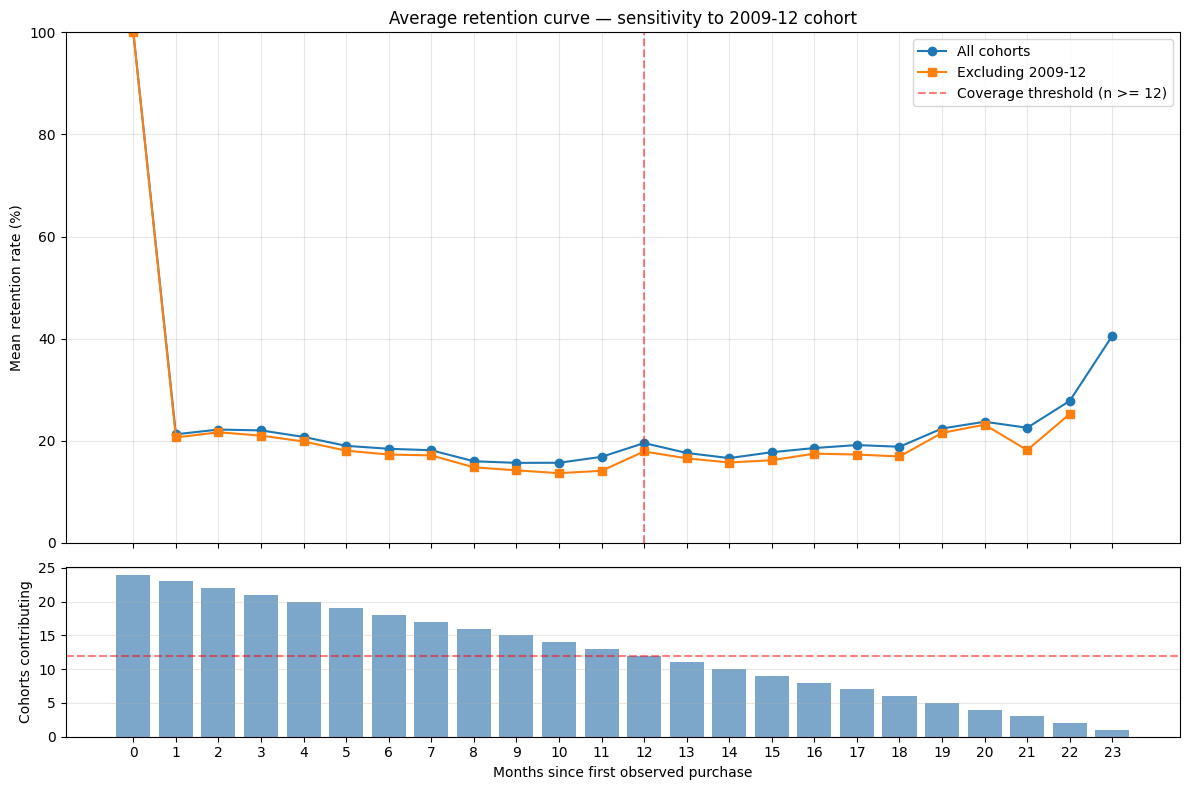

Mean retention by period (with cohort coverage):
               all_cohorts_pct  excluding_2009_12_pct  cohorts_contributing  difference
cohort_period                                                                          
0                       100.00                 100.00                    24        0.00
1                        21.29                  20.66                    23        0.63
2                        22.22                  21.69                    22        0.53
3                        22.05                  21.03                    21        1.02
4                        20.78                  19.88                    20        0.90
5                        19.03                  18.09                    19        0.94
6                        18.45                  17.32                    18        1.13
7                        18.17                  17.15                    17        1.02
8                        16.01                  14.83                  

In [12]:
# Mean retention per period, including all cohorts.
mean_retention_all = retention_matrix.mean(axis=0)

# Mean retention per period, excluding the 2009-12 cohort.
mean_retention_excluding_first = (
    retention_matrix.drop(index=pd.Period("2009-12", freq="M")).mean(axis=0)
)

# Number of cohorts contributing to each period's average.
cohorts_per_period = retention_matrix.notna().sum(axis=0)

# Coverage threshold: only periods where at least 12 cohorts are observable.
# Beyond this threshold the average is dominated by a small number of
# long-observed cohorts and is not a reliable summary of customer behaviour.
coverage_threshold = 12
covered_periods = cohorts_per_period[cohorts_per_period >= coverage_threshold].index

# Two-panel figure: retention curves on top, contributing cohort counts below.
figure, (axis_top, axis_bottom) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axis_top.plot(
    mean_retention_all.index,
    mean_retention_all * 100,
    marker="o",
    label="All cohorts",
)
axis_top.plot(
    mean_retention_excluding_first.index,
    mean_retention_excluding_first * 100,
    marker="s",
    label="Excluding 2009-12",
)
axis_top.axvline(
    x=covered_periods.max(),
    color="red",
    linestyle="--",
    alpha=0.5,
    label=f"Coverage threshold (n >= {coverage_threshold})",
)
axis_top.set_title("Average retention curve — sensitivity to 2009-12 cohort")
axis_top.set_ylabel("Mean retention rate (%)")
axis_top.set_ylim(0, 100)
axis_top.grid(True, alpha=0.3)
axis_top.legend()

axis_bottom.bar(
    cohorts_per_period.index,
    cohorts_per_period.values,
    color="steelblue",
    alpha=0.7,
)
axis_bottom.axhline(
    y=coverage_threshold, color="red", linestyle="--", alpha=0.5,
)
axis_bottom.set_xlabel("Months since first observed purchase")
axis_bottom.set_ylabel("Cohorts contributing")
axis_bottom.set_xticks(range(0, 24))
axis_bottom.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Comparison table with cohort coverage.
comparison = pd.DataFrame({
    "all_cohorts_pct": (mean_retention_all * 100).round(2),
    "excluding_2009_12_pct": (mean_retention_excluding_first * 100).round(2),
    "cohorts_contributing": cohorts_per_period.values,
})
comparison["difference"] = (
    comparison["all_cohorts_pct"] - comparison["excluding_2009_12_pct"]
).round(2)

print("Mean retention by period (with cohort coverage):")
print(comparison.to_string())
print()
print(
    f"Periods with cohort coverage >= {coverage_threshold}: "
    f"{covered_periods.min()} to {covered_periods.max()}"
)
print(
    "Beyond this range, the average is dominated by a small number of "
    "long-observed cohorts and is not analytically reliable."
)

In [13]:
# Extract the figures used in the Findings narrative below. If the underlying
# analysis changes, these printouts will reveal any drift from the markdown.
mean_period_1_all = mean_retention_all.loc[1] * 100
mean_period_1_excluding_first = mean_retention_excluding_first.loc[1] * 100

# Well-covered window: periods 1-11 (>= 13 cohorts contribute).
well_covered_start = mean_retention_all.loc[1] * 100
well_covered_end = mean_retention_all.loc[11] * 100
well_covered_start_excl = mean_retention_excluding_first.loc[1] * 100
well_covered_end_excl = mean_retention_excluding_first.loc[11] * 100

# 2009-12 cohort observable range.
cohort_2009_12 = retention_matrix.loc[pd.Period("2009-12", freq="M")]
cohort_2009_12_min = cohort_2009_12.iloc[1:].min() * 100
cohort_2009_12_max = cohort_2009_12.iloc[1:].max() * 100

# Cohort size distribution.
cohort_sizes_pre_dec_2010 = cohort_sizes[
    cohort_sizes["cohort_month"] < pd.Period("2010-12", freq="M")
]["cohort_size"]
cohort_sizes_dec_2010_to_july_2011 = cohort_sizes[
    (cohort_sizes["cohort_month"] >= pd.Period("2010-12", freq="M"))
    & (cohort_sizes["cohort_month"] <= pd.Period("2011-07", freq="M"))
]["cohort_size"]

print("Figures used in the Findings narrative:")
print()
print(f"Mean period-1 retention (all cohorts):           {mean_period_1_all:.1f}%")
print(f"Mean period-1 retention (excluding 2009-12):     {mean_period_1_excluding_first:.1f}%")
print()
print(f"Well-covered window (periods 1-11), all cohorts:        "
      f"{well_covered_start:.1f}% to {well_covered_end:.1f}%")
print(f"Well-covered window (periods 1-11), excluding 2009-12:  "
      f"{well_covered_start_excl:.1f}% to {well_covered_end_excl:.1f}%")
print()
print(f"2009-12 cohort retention range (periods 1-23):   "
      f"{cohort_2009_12_min:.1f}% to {cohort_2009_12_max:.1f}%")
print()
print(f"Cohort sizes (through Nov 2010):       "
      f"mean {cohort_sizes_pre_dec_2010.mean():.0f}, "
      f"min {cohort_sizes_pre_dec_2010.min()}, "
      f"max {cohort_sizes_pre_dec_2010.max()}")
print(f"Cohort sizes (Dec 2010 to Jul 2011):   "
      f"mean {cohort_sizes_dec_2010_to_july_2011.mean():.0f}, "
      f"min {cohort_sizes_dec_2010_to_july_2011.min()}, "
      f"max {cohort_sizes_dec_2010_to_july_2011.max()}")

Figures used in the Findings narrative:

Mean period-1 retention (all cohorts):           21.3%
Mean period-1 retention (excluding 2009-12):     20.7%

Well-covered window (periods 1-11), all cohorts:        21.3% to 16.9%
Well-covered window (periods 1-11), excluding 2009-12:  20.7% to 14.1%

2009-12 cohort retention range (periods 1-23):   24.4% to 49.6%

Cohort sizes (through Nov 2010):       mean 353, min 163, max 951
Cohort sizes (Dec 2010 to Jul 2011):   mean 110, min 72, max 179


In [14]:
# Cohort sizes excluding 2009-12 for a comparison free of the left-truncation effect.
cohort_sizes_pre_dec_2010_excl_first = cohort_sizes[
    (cohort_sizes["cohort_month"] >= pd.Period("2010-01", freq="M"))
    & (cohort_sizes["cohort_month"] < pd.Period("2010-12", freq="M"))
]["cohort_size"]

print(f"Cohort sizes (Jan-Nov 2010 only):      "
      f"mean {cohort_sizes_pre_dec_2010_excl_first.mean():.0f}, "
      f"min {cohort_sizes_pre_dec_2010_excl_first.min()}, "
      f"max {cohort_sizes_pre_dec_2010_excl_first.max()}")

Cohort sizes (Jan-Nov 2010 only):      mean 299, min 163, max 441


## Findings

**Most customers do not return after their first purchase month.** Mean period-1 retention is 21.3% across all cohorts (20.7% excluding 2009-12). The transition from period 0 (100%) to period 1 is the largest single-period drop in every cohort's retention curve. This is the dominant signal in the data.

**Retention is flat-to-declining across the well-covered window.** Within periods 1 through 11 — where at least 13 cohorts contribute to each average — mean retention drifts from 21.3% to 16.9% (20.7% to 14.1% excluding 2009-12), with no clear recovery pattern.

**The apparent late-period recovery is a triangular-matrix artifact, not customer behaviour.** Periods 13 onwards are averaged from progressively fewer cohorts (11 down to 1). The 2009-12 cohort, which has higher retention than any other cohort across all of its observable periods, increasingly dominates the average as the right edge approaches. Removing 2009-12 partially attenuates this effect, but the artifact reproduces because 2010-01 then becomes the longest-observed cohort. Right-edge averages are reported in the comparison table but should not be interpreted as a retention pattern.

**The 2009-12 cohort has higher sustained retention than any other cohort.** Across observable periods 1-23, 2009-12 retention ranges from 24.4% to 49.6%, while no other cohort sustains comparable values. First observed purchase month is a proxy for acquisition throughout the dataset, but the 2009-12 cohort sits at the dataset boundary and cannot be distinguished from pre-existing customers whose earlier purchases fall outside the data window. The sensitivity check is the partial guard against this; treating 2009-12 as data-boundary-suspect is the conservative interpretation.

**Cohort acquisition volume collapses in December 2010 and stays low for eight months.** New customer acquisition drops from 326 in November 2010 to 76 in December 2010 — a 77% month-over-month decline and the single largest acquisition-volume change in the dataset. From December 2010 through July 2011, cohorts average 110 customers (min 72, max 179), compared to 299 customers (min 163, max 441) for the January-November 2010 baseline. Volume partially recovers from August 2011 onward (107-221 per month). The cause is not determinable from the cohort table alone.

## Save outputs

Save long-form retention, retention matrix, active customer matrix, and cohort sizes to `data/processed/`. Period columns are converted to strings before writing because pyarrow does not support Period natively.

In [15]:
output_directory = Path("../data/processed")

# Long-form: convert cohort_month Period to string for parquet compatibility.
cohort_retention_long_to_save = cohort_retention_long.copy()
cohort_retention_long_to_save["cohort_month"] = (
    cohort_retention_long_to_save["cohort_month"].astype(str)
)
cohort_retention_long_to_save.to_parquet(
    output_directory / "cohort_retention_long.parquet",
    index=False,
)

# Retention matrix: convert Period index to string.
retention_matrix_to_save = retention_matrix.copy()
retention_matrix_to_save.index = retention_matrix_to_save.index.astype(str)
retention_matrix_to_save.to_parquet(
    output_directory / "cohort_retention_matrix.parquet",
)

# Active customer matrix derived from cohort_grid.
active_customer_matrix = cohort_grid.pivot(
    index="cohort_month",
    columns="cohort_period",
    values="active_customer_count",
)

# Matrix shape must match the retention matrix.
assert active_customer_matrix.shape == retention_matrix.shape, (
    f"Active customer matrix shape {active_customer_matrix.shape} "
    f"does not match retention matrix {retention_matrix.shape}."
)

# Non-NaN cell count must equal the observable grid size.
assert active_customer_matrix.notna().sum().sum() == len(cohort_grid), (
    "Active customer matrix non-NaN cells do not match cohort_grid row count."
)

# Period 0 active count must equal cohort_size for every cohort.
# Period 0 active count must equal cohort_size for every cohort, aligned by label.
period_0_check = (
    active_customer_matrix[0]
    .rename("active_period_0")
    .reset_index()
    .merge(cohort_sizes, on="cohort_month", how="outer")
)
assert period_0_check["active_period_0"].notna().all(), (
    "Cohort missing from active_customer_matrix period-0 column."
)
assert period_0_check["cohort_size"].notna().all(), (
    "Cohort missing from cohort_sizes."
)
assert (
    period_0_check["active_period_0"] == period_0_check["cohort_size"]
).all(), "Period-0 active count does not match cohort_size."

active_customer_matrix.index = active_customer_matrix.index.astype(str)
active_customer_matrix.to_parquet(
    output_directory / "cohort_active_customer_matrix.parquet",
)

# Cohort sizes: convert Period to string.
cohort_sizes_to_save = cohort_sizes.copy()
cohort_sizes_to_save["cohort_month"] = (
    cohort_sizes_to_save["cohort_month"].astype(str)
)
cohort_sizes_to_save.to_parquet(
    output_directory / "cohort_sizes.parquet",
    index=False,
)

# Verify all four files exist and report their sizes.
saved_files = [
    "cohort_retention_long.parquet",
    "cohort_retention_matrix.parquet",
    "cohort_active_customer_matrix.parquet",
    "cohort_sizes.parquet",
]
for file_name in saved_files:
    file_path = output_directory / file_name
    assert file_path.exists(), f"{file_name} was not written."
    print(f"{file_name}: {file_path.stat().st_size / 1024:.1f} KB")

print()
print("All four outputs saved successfully.")

cohort_retention_long.parquet: 6.9 KB
cohort_retention_matrix.parquet: 15.5 KB
cohort_active_customer_matrix.parquet: 14.7 KB
cohort_sizes.parquet: 1.9 KB

All four outputs saved successfully.


## Stage 4 summary

**Input:** `data/processed/online_retail_cleaned.parquet` — 776,579 transactions, 5,852 unique customers, 36,594 invoices, total revenue £17,068,582.72 (2009-12-01 to 2011-12-09).

**Analysis window:** 2009-12-01 to 2011-11-30. December 2011 was excluded from the primary monthly analysis because the dataset ends 2011-12-09, making the month incomplete. 16,964 transactions and 28 customers were excluded.

**Cohort definition:** First observed purchase month, a transaction-based proxy for acquisition because the dataset does not contain customer signup or registration events.

**Retention metric:** Active customers in period N as a percentage of cohort size at period 0.

**Time grain:** Monthly. 24 cohorts spanning 2009-12 to 2011-11, period offsets 0 to 23.

**Right-censoring:** Handled with an explicit observable cohort-period grid. Cells beyond a cohort's observable window are NaN, not zero. Observable cells with no active customers would be zero, though this dataset has no such cells.

**Outputs saved to `data/processed/`:**
- `cohort_retention_long.parquet` — main analytical output (300 rows).
- `cohort_retention_matrix.parquet` — 24 × 24 retention matrix, fractions.
- `cohort_active_customer_matrix.parquet` — 24 × 24 active count matrix.
- `cohort_sizes.parquet` — one row per cohort.